# Exploração dos dados Sentinel-2 L2A

Este notebook explora o catálogo STAC Bronze, as cenas representativas e os COGs `red`, `nir`, `swir16` e `scl`. Caso a fonte ainda não tenha sido baixada, as células indicam o comando necessário sem interromper a execução.

## Disponibilidade local

Os arquivos Sentinel-2 são grandes e não são versionados. A primeira célula verifica catálogo e COGs locais; ausência não representa erro do projeto, apenas uma ingestão ainda não executada neste ambiente.

In [6]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from affine import Affine
from rasterio.enums import Resampling
from rasterio.vrt import WarpedVRT

PROJECT_ROOT = Path(".") if Path("data").exists() else Path("..")
SENTINEL_ROOT = PROJECT_ROOT / "data/bronze/sentinel_2/l2a/municipality_code=5107925"
CATALOG_PATH = SENTINEL_ROOT / "start_date=2023-09-01/end_date=2024-04-30/search-results.json"
ASSET_PATHS = sorted(SENTINEL_ROOT.glob("item_id=*/*.tif"))
catalog_available = CATALOG_PATH.exists()
assets_available = bool(ASSET_PATHS)

print(f"Catálogo disponível: {catalog_available}")
print(f"COGs disponíveis: {len(ASSET_PATHS)}")
if not catalog_available:
    print("Execute: uv run python -m water_stress.pipelines.run_ingestion --source sentinel-2")

Catálogo disponível: True
COGs disponíveis: 8


## Catálogo de cenas

Quando disponível, o catálogo completo mostra a distribuição temporal e a cobertura de nuvens de todas as cenas elegíveis. Isso permite entender o universo do qual as três cenas representativas foram escolhidas.

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
item_id,131,131,S2A_21LXG_20230903_0_L2A,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
acquired_at,131,NaN,NaN,NaN,2023-12-13 23:04:46.975732992+00:00,2023-09-03 14:06:02.010000+00:00,2023-10-01 02:05:51.661000192+00:00,2023-12-07 14:06:07.936999936+00:00,2024-02-25 14:05:57.852000+00:00,2024-04-30 14:06:28.491000+00:00,NaN
cloud_cover_pct,131.0,NaN,NaN,NaN,13.13151,0.010395,4.939526,12.84426,19.948364,29.912972,8.600309
platform,131,2,sentinel-2b,80,NaN,NaN,NaN,NaN,NaN,NaN,NaN


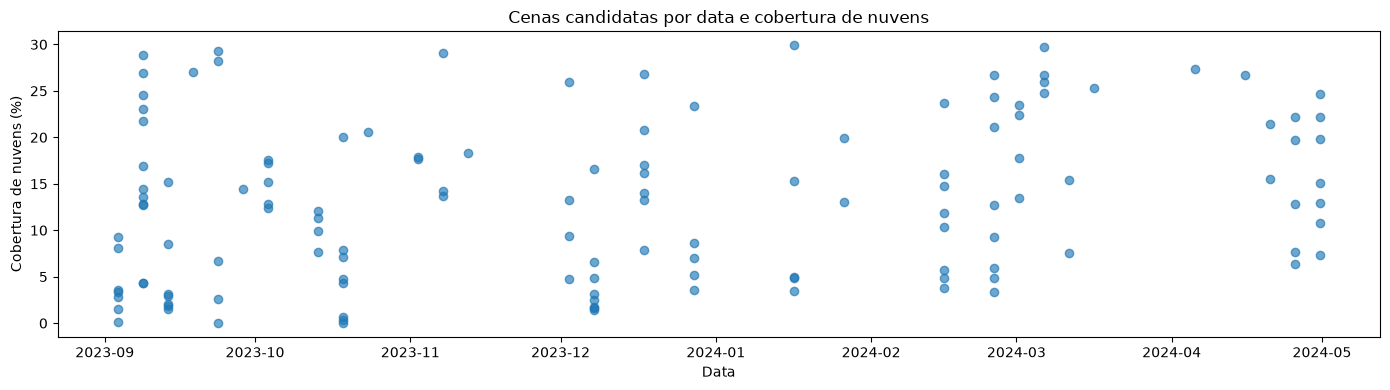

In [7]:
catalog_table = pd.DataFrame()
if catalog_available:
    catalog = json.loads(CATALOG_PATH.read_text(encoding="utf-8"))
    catalog_table = pd.DataFrame(
        [
            {
                "item_id": item["id"],
                "acquired_at": pd.to_datetime(item["properties"]["datetime"]),
                "cloud_cover_pct": item["properties"].get("eo:cloud_cover"),
                "platform": item["properties"].get("platform"),
            }
            for item in catalog["features"]
        ]
    ).sort_values("acquired_at")
    display(catalog_table.describe(include="all").T)
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.scatter(
        catalog_table["acquired_at"],
        catalog_table["cloud_cover_pct"],
        alpha=0.65,
    )
    ax.set(
        title="Cenas candidatas por data e cobertura de nuvens",
        xlabel="Data",
        ylabel="Cobertura de nuvens (%)",
    )
    fig.tight_layout()
    plt.show()
else:
    print("Catálogo ainda não disponível para exploração.")

## Metadados dos COGs selecionados

A tabela verifica dimensões, CRS, resolução, tipo e `nodata` de cada banda. Diferenças de resolução são esperadas: bandas espectrais e a classificação SCL podem precisar de reamostragem na futura camada Silver.

In [8]:
asset_rows = []
for path in ASSET_PATHS:
    with rasterio.open(path) as source:
        asset_rows.append(
            {
                "item_id": path.parent.name.split("=", 1)[1],
                "asset": path.stem,
                "width": source.width,
                "height": source.height,
                "crs": str(source.crs),
                "resolution_x": source.res[0],
                "resolution_y": source.res[1],
                "dtype": source.dtypes[0],
                "nodata": source.nodata,
            }
        )
asset_inventory = pd.DataFrame(asset_rows)
asset_inventory if not asset_inventory.empty else pd.DataFrame(
    {"status": ["Nenhum COG local; execute a ingestão Sentinel-2."]}
)

,item_id,asset,width,height,crs,resolution_x,resolution_y,dtype,nodata
0,S2A_21LXF_20230913_0_L2A,nir,10980,10980,EPSG:32721,10.0,10.0,uint16,0.0
1,S2A_21LXF_20230913_0_L2A,red,10980,10980,EPSG:32721,10.0,10.0,uint16,0.0
2,S2A_21LXF_20230913_0_L2A,scl,5490,5490,EPSG:32721,20.0,20.0,uint8,0.0
3,S2A_21LXF_20230913_0_L2A,swir16,5490,5490,EPSG:32721,20.0,20.0,uint16,0.0
4,S2B_21LXF_20231207_0_L2A,nir,10980,10980,EPSG:32721,10.0,10.0,uint16,0.0
5,S2B_21LXF_20231207_0_L2A,red,10980,10980,EPSG:32721,10.0,10.0,uint16,0.0
6,S2B_21LXF_20231207_0_L2A,scl,5490,5490,EPSG:32721,20.0,20.0,uint8,0.0
7,S2B_21LXF_20231207_0_L2A,swir16,5490,5490,EPSG:32721,20.0,20.0,uint16,0.0


## Prévia das bandas e máscara SCL

Para cada cena local, as bandas são lidas com redução de resolução apenas para visualização. `red`, `nir` e `swir16` representam reflectância codificada; `scl` contém classes discretas de qualidade e cobertura da superfície.

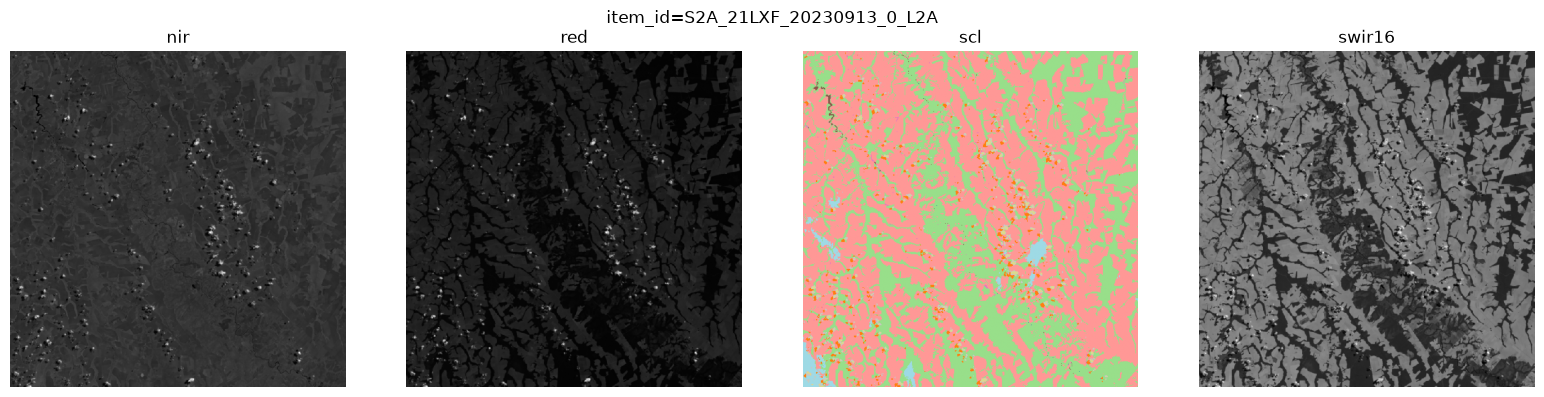

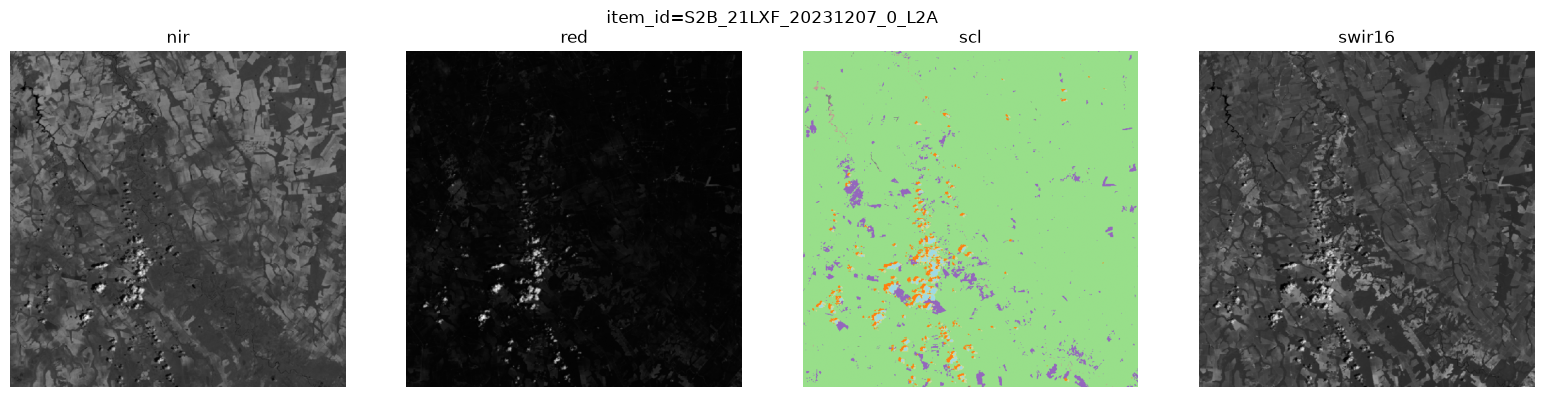

In [9]:
item_directories = sorted({path.parent for path in ASSET_PATHS})
for item_directory in item_directories:
    available = {path.stem: path for path in item_directory.glob("*.tif")}
    fig, axes = plt.subplots(1, len(available), figsize=(4 * len(available), 4))
    axes = np.atleast_1d(axes)
    for axis, (asset_name, path) in zip(axes, sorted(available.items()), strict=True):
        with rasterio.open(path) as source:
            scale = max(source.height // 500, source.width // 500, 1)
            preview = source.read(
                1, out_shape=(source.height // scale, source.width // scale), masked=True
            )
        color_map = "tab20" if asset_name == "scl" else "gray"
        axis.imshow(preview, cmap=color_map)
        axis.set_title(asset_name)
        axis.set_axis_off()
    fig.suptitle(item_directory.name)
    fig.tight_layout()
    plt.show()
if not item_directories:
    print("Prévia aguardando o download dos COGs Sentinel-2.")

## Diagnóstico exploratório de NDVI e NDMI

As bandas possuem resoluções nativas diferentes: vermelho e NIR têm 10 m, enquanto SWIR16 tem 20 m. Para o diagnóstico, todas são alinhadas somente em memória à grade de 20 m da SWIR16, com reamostragem bilinear. A leitura é limitada a 2048 pixels por eixo para controlar o uso de memória. O notebook calcula NDVI `(NIR - red) / (NIR + red)` e NDMI `(NIR - SWIR) / (NIR + SWIR)`. Esses resultados são exploratórios: máscara SCL, recorte municipal e harmonização formal ainda pertencem à transformação Silver.

In [10]:
index_rows = []
for item_directory in item_directories:
    paths = {name: item_directory / f"{name}.tif" for name in ("red", "nir", "swir16")}
    if not all(path.exists() for path in paths.values()):
        continue
    with rasterio.open(paths["swir16"]) as reference:
        target_width = min(reference.width, 2048)
        target_height = min(reference.height, 2048)
        target_transform = reference.transform * Affine.scale(
            reference.width / target_width,
            reference.height / target_height,
        )
        target_options = {
            "crs": reference.crs,
            "transform": target_transform,
            "width": target_width,
            "height": target_height,
            "resampling": Resampling.bilinear,
        }
        arrays = {}
        for name, path in paths.items():
            with rasterio.open(path) as source, WarpedVRT(source, **target_options) as aligned:
                arrays[name] = aligned.read(1, masked=True).astype("float32")
    with np.errstate(divide="ignore", invalid="ignore"):
        ndvi = (arrays["nir"] - arrays["red"]) / (arrays["nir"] + arrays["red"])
        ndmi = (arrays["nir"] - arrays["swir16"]) / (arrays["nir"] + arrays["swir16"])
    index_rows.append(
        {
            "item_id": item_directory.name,
            "status": "alinhado a SWIR16; sem máscara SCL",
            "analysis_shape": f"{target_height}x{target_width}",
            "ndvi_mean": float(np.ma.mean(ndvi)),
            "ndmi_mean": float(np.ma.mean(ndmi)),
        }
    )
pd.DataFrame(index_rows) if index_rows else pd.DataFrame(
    {"status": ["Índices aguardando bandas locais compatíveis."]}
)

,item_id,status,analysis_shape,ndvi_mean,ndmi_mean
0,item_id=S2A_21LXF_20230913_0_L2A,alinhado a SWIR16; sem máscara SCL,2048x2048,0.371969,-0.125436
1,item_id=S2B_21LXF_20231207_0_L2A,alinhado a SWIR16; sem máscara SCL,2048x2048,0.767374,0.219406
